# Denoising DCS g2(τ) curves

This notebook shows how to use `dcs_denoiser` to denoise diffuse correlation spectroscopy intensity autocorrelation curves.

Install the package first, from the repository root: `pip install -e ".[examples]"`.

The curves here are synthetic (`synthetic_dcs.py`), so the notebook runs without any data files and the true clean curve is known.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dcs_denoiser import load_denoiser
from synthetic_dcs import example_curves

## 1. Load the model

`load_denoiser()` loads the checkpoint bundled with the package. The checkpoint carries the network weights, the LSTM shape and the lag-time normalisation constants, so there is nothing else to configure.

In [2]:
denoiser = load_denoiser()
print(denoiser)
print("trained lag-time range (s):", denoiser.tau_range_s)

DCSDenoiser(device=cpu, trained tau range=[5e-08, 5] s)
trained lag-time range (s): (5.001369793817555e-08, 4.998599423184952)


## 2. Get some curves

The denoiser needs two things:

- `taus`: lag times in **seconds**, shape `(n_tau,)`, strictly increasing
- `g2`: intensity autocorrelation curves, shape `(..., n_tau)`. These are plain g2 (decaying from `1 + β` to 1), **not** `g2 − 1`.

Here: one clean semi-infinite curve (ρ = 2.5 cm, αDb = 1e-8 cm²/s, β = 0.5) and 50 noisy realisations of it.

In [3]:
taus, g2_clean, g2_noisy = example_curves(n_repeats=50, rho=2.5, aDb=1e-8, beta=0.5)
print("taus:", taus.shape, " g2_noisy:", g2_noisy.shape)

taus: (128,)  g2_noisy: (50, 128)


## 3. Denoise

Every curve along the last axis is denoised independently, so the input can have any leading shape, for example `(time, channel, n_tau)`. The output has the same shape as the input.

In [4]:
g2_denoised = denoiser.denoise(g2_noisy, taus)

rmse = lambda x: np.sqrt(np.mean((x - g2_clean) ** 2))
print(f"RMSE vs clean curve:  noisy {rmse(g2_noisy):.4f}   denoised {rmse(g2_denoised):.4f}")

RMSE vs clean curve:  noisy 0.0586   denoised 0.0103


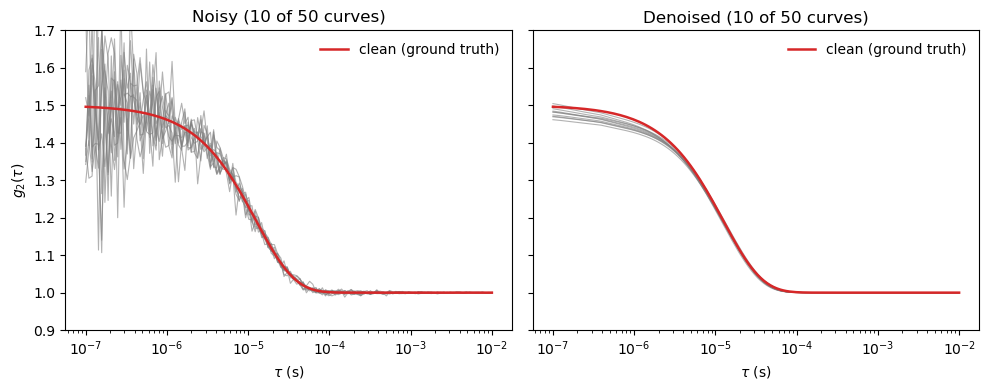

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, curves, title in ((axes[0], g2_noisy, "Noisy"), (axes[1], g2_denoised, "Denoised")):
    ax.semilogx(taus, curves[:10].T, lw=0.8, alpha=0.6, color="tab:gray")
    ax.semilogx(taus, g2_clean, lw=1.8, color="tab:red", label="clean (ground truth)")
    ax.set_title(f"{title} (10 of {len(curves)} curves)")
    ax.set_xlabel(r"$\tau$ (s)")
    ax.legend(frameon=False)
axes[0].set_ylabel(r"$g_2(\tau)$")
axes[0].set_ylim(0.9, 1.7)
fig.tight_layout()

## 4. Using your own data

Replace `taus` and `g2_noisy` above with your measurement. Things to check:

- **Units.** `taus` must be in seconds. A warning is raised if lag times fall outside the range the model was trained on.
- **Zero lag.** A `tau = 0` bin cannot be log-normalised. It is not shown to the network and is returned unchanged.
- **Bad curves.** A curve containing NaN or inf is returned unchanged.
- **Output floor.** The output is always ≥ 1.


For a single call without keeping a model object around, `from dcs_denoiser import denoise` and call `denoise(g2, taus)`.